# Análise Comparativa de Arquiteturas CNN

## Objetivo
Este notebook centraliza a avaliação de todos os experimentos realizados no dataset FER2013. O objetivo é ler os arquivos de histórico (`.csv`) gerados durante o treinamento das diferentes redes (CNN Customizada, VGG16, variantes da ResNet50 e EfficientNetB0) e plotar gráficos comparativos.

## Métricas Analisadas
* **Acurácia de Validação (`val_accuracy`):** Indica a capacidade de generalização do modelo em imagens inéditas.
* **Perda de Validação (`val_loss`):** Fundamental para diagnosticar *overfitting* (quando a rede decora o treino, mas erra no teste).

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Dicionário com os nomes dos modelos e seus respectivos arquivos CSV
arquivos_historico = {
    'CNN Baseline': '../../reports/historico_cnn_customizada.csv',
    'VGG16 (Transfer)': 'historico_vgg16_fer2013.csv',
    'ResNet50 (Baseline)': '../../reports/historico_resnet50_fer2013.csv',
    'ResNet50 (UpSampling)': 'historico_resnet50_upsampling.csv',
    'ResNet50 (Fine-Tuning)': 'historico_resnet50_finetuning.csv',
    'EfficientNetB0': '../../reports/historico_efficientnetb0_fer2013.csv'
}

dados_modelos = {}

print("Procurando resultados dos experimentos...\n")

for nome_modelo, arquivo in arquivos_historico.items():
    if os.path.exists(arquivo):
        # Lê o CSV usando pandas
        df = pd.read_csv(arquivo)
        dados_modelos[nome_modelo] = df
        print(f"✅ [{nome_modelo}] carregado com sucesso. ({len(df)} épocas registradas)")
    else:
        print(f"❌ [{nome_modelo}] Arquivo '{arquivo}' não encontrado. Ele será ignorado no gráfico.")

print("\nDados prontos para visualização!")

Procurando resultados dos experimentos...

✅ [CNN Baseline] carregado com sucesso. (30 épocas registradas)
✅ [VGG16 (Transfer)] carregado com sucesso. (30 épocas registradas)
✅ [ResNet50 (Baseline)] carregado com sucesso. (60 épocas registradas)
✅ [ResNet50 (UpSampling)] carregado com sucesso. (30 épocas registradas)
✅ [ResNet50 (Fine-Tuning)] carregado com sucesso. (30 épocas registradas)
✅ [EfficientNetB0] carregado com sucesso. (31 épocas registradas)

Dados prontos para visualização!


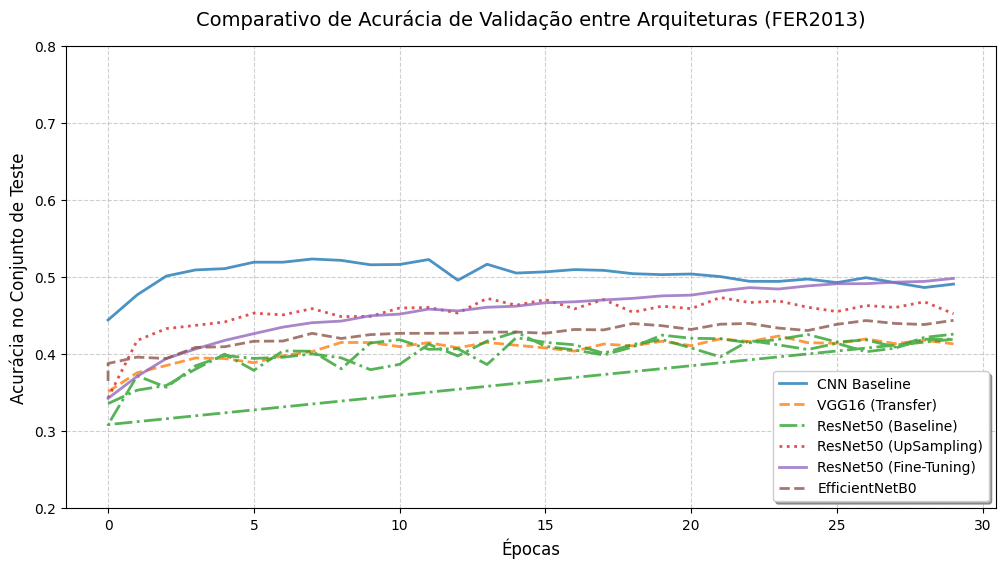

In [3]:
plt.figure(figsize=(12, 6))

# Define estilos de linha para diferenciar visualmente (linhas contínuas, tracejadas, etc.)
estilos = ['-', '--', '-.', ':', '-', '--']
marcadores = ['o', 's', '^', 'D', 'v', '*']

for (nome_modelo, df), estilo, marcador in zip(dados_modelos.items(), estilos, marcadores):
    # Plotando a acurácia de validação (o que realmente importa)
    plt.plot(df['epoch'], df['val_accuracy'], label=nome_modelo, linestyle=estilo, linewidth=2, alpha=0.8)

plt.title('Comparativo de Acurácia de Validação entre Arquiteturas (FER2013)', fontsize=14, pad=15)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Acurácia no Conjunto de Teste', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right', fontsize=10, shadow=True)

# Define os limites do eixo Y para facilitar a leitura (de 20% a 80%)
plt.ylim(0.2, 0.8) 

# Salva o gráfico em alta resolução para usar no documento final
plt.savefig('../../reports/figures/comparativo_acuracia_modelos.png', dpi=300, bbox_inches='tight')

plt.show()

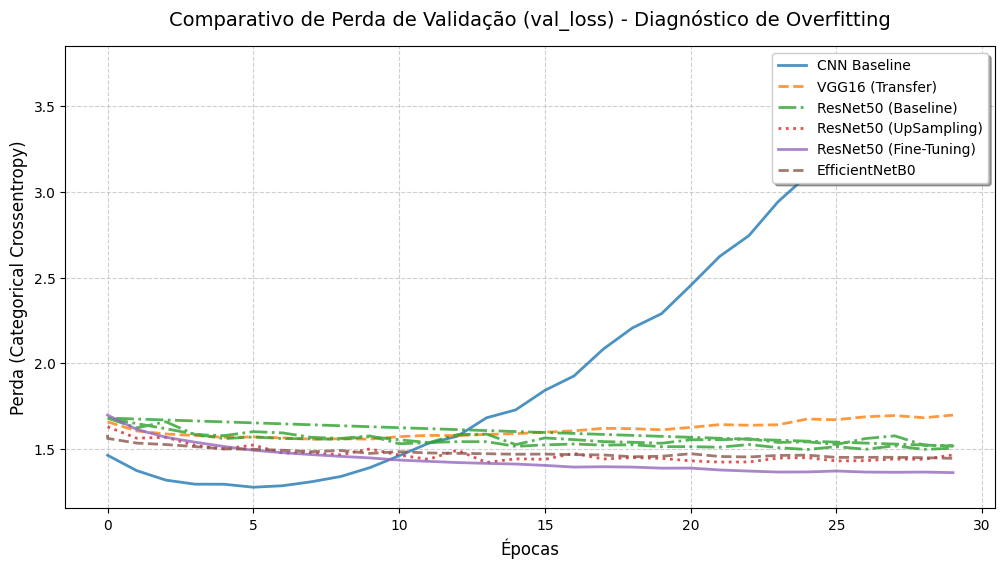

In [4]:
plt.figure(figsize=(12, 6))

for (nome_modelo, df), estilo in zip(dados_modelos.items(), estilos):
    # Plotando a Perda de Validação (val_loss)
    plt.plot(df['epoch'], df['val_loss'], label=nome_modelo, linestyle=estilo, linewidth=2, alpha=0.8)

plt.title('Comparativo de Perda de Validação (val_loss) - Diagnóstico de Overfitting', fontsize=14, pad=15)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Perda (Categorical Crossentropy)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', fontsize=10, shadow=True)

# Salva o gráfico
plt.savefig('../../reports/figures/comparativo_loss_modelos.png', dpi=300, bbox_inches='tight')

plt.show()